In [1]:
%load_ext autoreload
%autoreload 2
import mdtraj as md
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as ticker
plt.style.use('rotskoff')
rotskoff_cmap = mpl.colors.LinearSegmentedColormap.from_list("mycmap", ['#1B346C','#01ABE9','#F1F8F1','#F54B1A'])
rotskoff_cmap_2 = mpl.colors.LinearSegmentedColormap.from_list("mycmap", ['#FFFFFF', '#820000'])
from openmm import unit
from typing import Optional, List, Tuple
from einops import rearrange, reduce, repeat
PATH = "/global/common/software/nersc9/texlive/2024/bin/x86_64-linux"
import os
os.environ["PATH"] += ":" + PATH
import subprocess
subprocess.run(['which', 'tex'], stdout=subprocess.PIPE)

CompletedProcess(args=['which', 'tex'], returncode=0, stdout=b'/global/common/software/nersc9/texlive/2024/bin/x86_64-linux/tex\n')

In [56]:
def rmsd_np(P, Q):
    """
    Compute RMSD per frame using Theobald's method (no explicit alignment).
    
    P: (n_frames, n_atoms, 3)
    Q: (n_frames, n_atoms, 3)

    Returns:
        rmsd_per_frame: (n_frames,)
    """
    # Q = np.repeat(Q, P.shape[0], axis=0)  # Ensure Q has the same number of frames as P
    P = torch.tensor(P, dtype=torch.float32)
    Q = torch.tensor(Q, dtype=torch.float32)

    # Center both structures
    P_centered = P - P.mean(dim=1, keepdim=True)
    Q_centered = Q - Q.mean(dim=1, keepdim=True)

    # Compute covariance matrix
    C = torch.matmul(P_centered.transpose(1, 2), Q_centered)  # (n_frames, 3, 3)

    # SVD on covariance matrix
    V, S, W = torch.linalg.svd(C)
    det = torch.det(torch.matmul(V, W.transpose(-1, -2)))
    sign_correction = det.sign()
    S_corrected = S.clone()
    S_corrected[:, -1] *= sign_correction  # fix last singular value

    dot = 2 * torch.sum(S_corrected, dim=-1)

    # Compute squared norms
    P_norm_sq = torch.sum(P_centered ** 2, dim=(1, 2))
    Q_norm_sq = torch.sum(Q_centered ** 2, dim=(1, 2))

    # RMSD² = (||P||² + ||Q||² - 2 * sum(S)) / N
    # dot = 2 * torch.sum(S, dim=-1)
    rmsd_sq = (P_norm_sq + Q_norm_sq - dot) / P.shape[1]
    # rmsd_sq = torch.clamp(rmsd_sq, min=0.0)

    return torch.sqrt(rmsd_sq).numpy()



In [3]:
bba_pdb = md.load("/global/cfs/cdirs/m4235/boltz_files/bba/bba_1fme.pdb")
bba_ca_pdb = bba_pdb.atom_slice(bba_pdb.topology.select("name CA"))

bba_ca_p = np.load("/global/cfs/cdirs/m4235/boltz_files/bba/bba_ca_coords.npy")[::10]
ref_ca_p = bba_ca_pdb.xyz * 10

helix_pdb = md.load("/global/cfs/cdirs/m4235/boltz_files/bba/helix.pdb")
helix_ca_pdb = helix_pdb.atom_slice(helix_pdb.topology.select("name CA"))
helix_ca_p = helix_ca_pdb.xyz * 10

In [4]:
fg_pdb = md.load("/global/cfs/cdirs/m4235/boltz_files/bba/filtered.pdb")
fg_pdb = fg_pdb.atom_slice(fg_pdb.topology.select("protein"))
print(f"{fg_pdb.xyz.shape = }")
print([res.name for res in fg_pdb.topology.residues])
print(fg_pdb.n_residues)
print(fg_pdb.atom_slice(fg_pdb.topology.select("protein")).xyz.shape)

fg_pdb.xyz.shape = (1, 513, 3)
['GLU', 'GLN', 'TYR', 'THR', 'ALA', 'LYS', 'TYR', 'LYS', 'GLY', 'ARG', 'THR', 'PHE', 'ARG', 'ASN', 'GLU', 'LYS', 'GLU', 'LEU', 'ARG', 'ASP', 'PHE', 'ILE', 'GLU', 'LYS', 'PHE', 'LYS', 'GLY', 'ARG']
28
(1, 513, 3)


In [5]:
boltz_pdb = md.load("/global/cfs/cdirs/m4235/boltz_files/bba/boltz_inference/boltz_results_bba_inference/predictions/bba/bba_model_0.pdb")
print(f"{boltz_pdb.xyz.shape = }")
print([res.name for res in boltz_pdb.topology.residues])
print(boltz_pdb.n_residues)
print(boltz_pdb.atom_slice(boltz_pdb.top.select("protein")).xyz.shape)

boltz_pdb.xyz.shape = (1, 250, 3)
['GLU', 'GLN', 'TYR', 'THR', 'ALA', 'LYS', 'TYR', 'LYS', 'GLY', 'ARG', 'THR', 'PHE', 'ARG', 'ASN', 'GLU', 'LYS', 'GLU', 'LEU', 'ARG', 'ASP', 'PHE', 'ILE', 'GLU', 'LYS', 'PHE', 'LYS', 'GLY', 'ARG']
28
(1, 250, 3)


In [6]:
# Get the common atom indices between fg_pdb and boltz_pdb
fg_atom_indices = []

for res_idx, (fg_res, boltz_res) in enumerate(zip(fg_pdb.topology.residues, boltz_pdb.topology.residues)):
    # Get atoms in both residues
    fg_atoms = list(fg_res.atoms)
    boltz_atoms = list(boltz_res.atoms)
    
    # Find common atom names
    boltz_atom_names = {atom.name for atom in boltz_atoms}
    
    for fg_atom in fg_atoms:
        if fg_atom.name in boltz_atom_names:
            fg_atom_indices.append(fg_atom.index)

# Create new trajectory with only the common atoms
fg_filtered_traj = fg_pdb.atom_slice(fg_atom_indices)
print(f"Original fg_pdb atoms: {fg_pdb.n_atoms}")
print(f"Filtered fg_pdb atoms: {fg_filtered_traj.n_atoms}")
print(f"boltz_pdb atoms: {boltz_pdb.n_atoms}")

# check that the atom order is the same
filtered_atoms = [atom.name for atom in fg_filtered_traj.top.atoms]
boltz_atoms = [atom.name for atom in boltz_pdb.top.atoms]
print(filtered_atoms)
print(boltz_atoms)
print(f"{(filtered_atoms == boltz_atoms) = }")

Original fg_pdb atoms: 513
Filtered fg_pdb atoms: 250
boltz_pdb atoms: 250
['N', 'CA', 'CB', 'CG', 'CD', 'OE1', 'OE2', 'C', 'O', 'N', 'CA', 'CB', 'CG', 'CD', 'OE1', 'NE2', 'C', 'O', 'N', 'CA', 'CB', 'CG', 'CD1', 'CE1', 'CZ', 'OH', 'CD2', 'CE2', 'C', 'O', 'N', 'CA', 'CB', 'OG1', 'CG2', 'C', 'O', 'N', 'CA', 'CB', 'C', 'O', 'N', 'CA', 'CB', 'CG', 'CD', 'CE', 'NZ', 'C', 'O', 'N', 'CA', 'CB', 'CG', 'CD1', 'CE1', 'CZ', 'OH', 'CD2', 'CE2', 'C', 'O', 'N', 'CA', 'CB', 'CG', 'CD', 'CE', 'NZ', 'C', 'O', 'N', 'CA', 'C', 'O', 'N', 'CA', 'CB', 'CG', 'CD', 'NE', 'CZ', 'NH1', 'NH2', 'C', 'O', 'N', 'CA', 'CB', 'OG1', 'CG2', 'C', 'O', 'N', 'CA', 'CB', 'CG', 'CD1', 'CE1', 'CZ', 'CD2', 'CE2', 'C', 'O', 'N', 'CA', 'CB', 'CG', 'CD', 'NE', 'CZ', 'NH1', 'NH2', 'C', 'O', 'N', 'CA', 'CB', 'CG', 'OD1', 'ND2', 'C', 'O', 'N', 'CA', 'CB', 'CG', 'CD', 'OE1', 'OE2', 'C', 'O', 'N', 'CA', 'CB', 'CG', 'CD', 'CE', 'NZ', 'C', 'O', 'N', 'CA', 'CB', 'CG', 'CD', 'OE1', 'OE2', 'C', 'O', 'N', 'CA', 'CB', 'CG', 'CD1', 'CD2', 'C

In [7]:
print(bba_ca_p.shape)

(365234, 28, 3)


In [8]:
print(np.linalg.norm(bba_ca_p[0,0,:] - bba_ca_p[0,1,:]))
print(np.linalg.norm(ref_ca_p[0,0,:] - ref_ca_p[0,1,:]))

3.9785666
3.8323088


In [9]:
# get the sequence for bba in one-letter codes
bba_seq = "".join([res.code for res in bba_pdb.topology.residues])
print(bba_seq)

EQYTAKYKGRTFRNEKELRDFIEKFKGR


In [10]:
def transform_a(x):
        # x = (1 - x**8) / (1- x**12)
        x = np.log(x + 2)
        return x

def transform_b(x):
        # x = 1 - (1 / (1 + np.exp(3  - (0.75) *  x)))
        x = np.log(x + 1)
        return x

def get_bba_rc(ca_positions, topology=bba_ca_pdb.topology):
    # ca_positions should already be CA-only coordinates
    # Don't try to select CA again if it's already CA-only
    if ca_positions.shape[1] == len(topology.select("name CA")):
        # Already CA-only
        pass
    else:
        # Full structure, need to select CA
        ca_positions = ca_positions[:, topology.select("name CA"), :]
    
    ref0 = np.repeat(ref_ca_p, ca_positions.shape[0], axis=0)
    helix_ref = np.repeat(helix_ca_p, ca_positions.shape[0], axis=0)
    a = transform_a(rmsd_np(ca_positions[:, 15:26, :], helix_ref[:, 15:26, :]))
    b = transform_b(rmsd_np(ca_positions[:, 3:15, :], ref0[:, 3:15, :]))
    return np.concatenate([a[:, None], b[:, None]], axis=1)

Text(0, 0.5, 'TIC 1')

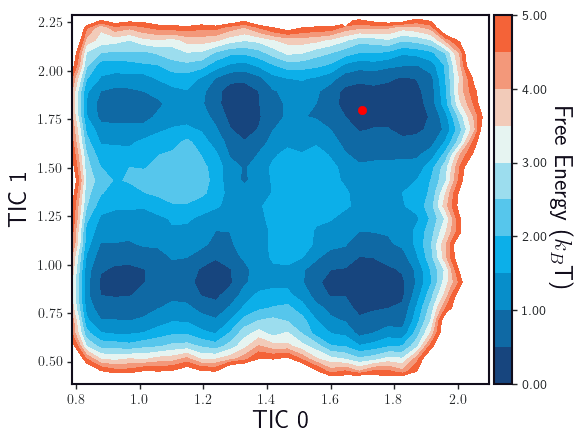

In [11]:
cv = get_bba_rc(bba_ca_p)

init_z, init_rc1_edge, init_rc2_edge = np.histogram2d(cv[:, 0], 
                                                      cv[:, 1],
                                                        bins=30)


init_rc1 = 0.5 * (init_rc1_edge[:-1] + init_rc1_edge[1:])
init_rc2 = 0.5 * (init_rc2_edge[:-1] + init_rc2_edge[1:])
init_z = init_z.T
init_z_density = init_z/float(init_z.sum())
init_free_energy = np.inf * np.ones(shape=init_z.shape)

nonzero = init_z_density.nonzero()
init_free_energy[nonzero] = -np.log(init_z_density[nonzero])
init_free_energy = init_free_energy - init_free_energy.min()

vmax = 5
plt.contourf(init_rc1, init_rc2, init_free_energy,
                levels=np.linspace(0, vmax, vmax * 2 + 1), cmap=rotskoff_cmap)
cbar = plt.colorbar(boundaries=np.linspace(0, vmax, vmax * 2 + 1), pad=0.01)
cbar.set_label(r"Free Energy ($k_B$T)", rotation=270, labelpad=20)
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
center = [1.7, 1.8]
plt.scatter(center[0], center[1], color='red')

plt.xlabel("TIC 0")
plt.ylabel("TIC 1")
# # plt.savefig("figures/trpcage/trpcage_schnet_free_energy.pdf", dpi=300)

In [12]:
# from boltz.lutils.pdb_processing import pdb_to_boltz_coords
# pdb_to_boltz_coords(
#     pdb_file="/global/cfs/cdirs/m4235/boltz_files/bba/filtered.pdb",
#     yaml_seq="EQYTAKYKGRTFRNEKELRDFIEKFKGR",
#     atom_mask=None,
#     device="cpu"
# )

In [13]:
# fg_folders = os.listdir("/home/scratch/group_scratch/cg/082825ProteinCVSetup/bba/0/filtered")
# fg_folders = [f"/home/scratch/group_scratch/cg/082825ProteinCVSetup/bba/0/filtered/{fg}" for fg in fg_folders if fg.startswith("e")]
# fg_files = [os.listdir(fg_folder) for fg_folder in fg_folders]
# fg_files = np.array([[f"{fg_folder}/{fg_file}" for fg_file in fg_file_list] for fg_folder, fg_file_list in zip(fg_folders, fg_files)])
# fg_files = fg_files.flatten()
# traj = md.load(fg_files, top=md.load("/home/scratch/group_scratch/cg/082825ProteinCVSetup/bba/2/filtered/filtered.pdb").topology, stride=10)

In [14]:
# print(traj.n_frames)
# traj = traj.center_coordinates()
# traj = traj.atom_slice(traj.topology.select("protein"))
# # traj[::100].save_pdb("test.pdb")

# fg_ca_p = traj.xyz[:, traj.topology.select("name CA"), :] * 10
# fg_cv = get_bba_rc(traj.xyz * 10, traj.topology)

In [15]:
# init_z, init_rc1_edge, init_rc2_edge = np.histogram2d(fg_cv[:, 0], 
#                                                       fg_cv[:, 1],
#                                                         bins=30)


# init_rc1 = 0.5 * (init_rc1_edge[:-1] + init_rc1_edge[1:])
# init_rc2 = 0.5 * (init_rc2_edge[:-1] + init_rc2_edge[1:])
# init_z = init_z.T
# init_z_density = init_z/float(init_z.sum())
# init_free_energy = np.inf * np.ones(shape=init_z.shape)

# nonzero = init_z_density.nonzero()
# init_free_energy[nonzero] = -np.log(init_z_density[nonzero])
# init_free_energy = init_free_energy - init_free_energy.min()

# vmax = 5
# plt.contourf(init_rc1, init_rc2, init_free_energy,
#                 levels=np.linspace(0, vmax, vmax * 2 + 1), cmap=rotskoff_cmap)
# cbar = plt.colorbar(boundaries=np.linspace(0, vmax, vmax * 2 + 1), pad=0.01)
# cbar.set_label(r"Free Energy ($k_B$T)", rotation=270, labelpad=20)
# cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
# center = [1.7, 1.8]
# # plt.scatter(fg_cv[:, 0], fg_cv[:, 1], color='red')

# plt.xlabel("TIC 0")
# plt.ylabel("TIC 1")

In [16]:
# _, x_edges, y_edges = np.histogram2d(cv[:, 0], cv[:, 1], bins=(11, 11))
# bin_centers_0 = 0.5 * (x_edges[:-1] + x_edges[1:])
# bin_centers_1 = 0.5 * (y_edges[:-1] + y_edges[1:])
# bin_centers = np.array(np.meshgrid(bin_centers_0, bin_centers_1)).T.reshape(-1, 2)

# width_0 = bin_centers_0[1] - bin_centers_0[0]
# width_1 = bin_centers_1[1] - bin_centers_1[0]

# centers = []

# for i in range(bin_centers.shape[0]):
#     bin_center = bin_centers[i]
#     x0, x1 = bin_center[0] - width_0 / 2, bin_center[0] + width_0 / 2
#     y0, y1 = bin_center[1] - width_1 / 2, bin_center[1] + width_1 / 2

#     mask = (fg_cv[:, 0] >= x0) & (fg_cv[:, 0] < x1) & (fg_cv[:, 1] >= y0) & (fg_cv[:, 1] < y1)
#     num_points = np.sum(mask)
#     if num_points > 0:
#         centers.append(bin_center)

# centers= np.array(centers)
# print(centers.shape)
# centers = centers[:100, :]

In [17]:
# fg_start = []
# for center in centers:
#     fg_start.append(np.argmin(np.linalg.norm(fg_cv - center, axis=1)))
# fg_start = np.array(fg_start)

In [18]:
# start_positions = traj.xyz[fg_start] * 10
# np.save("/home/scratch/group_scratch/cg/082825ProteinCVSetup/bias_force_bba_090325/start_positions.npy", start_positions)
# np.save("/home/scratch/group_scratch/cg/082825ProteinCVSetup/bias_force_bba_090325/centers.npy", centers)
# traj[0].save_pdb("/home/scratch/group_scratch/cg/082825ProteinCVSetup/bias_force_bba_090325/bba.pdb")
# traj[fg_start].center_coordinates().save_pdb("/home/scratch/group_scratch/cg/082825ProteinCVSetup/bias_force_bba_090325/start_positions.pdb")

In [19]:
start_positions = np.load("/global/cfs/cdirs/m4235/boltz_files/bba/start_positions.npy")
print(f"{start_positions.shape = }")
centers = np.load("/global/cfs/cdirs/m4235/boltz_files/bba/centers.npy")
print(f"{centers.shape = }")

start_positions.shape = (100, 513, 3)
centers.shape = (100, 2)


In [91]:
# save the start positions as pdbs as inputs for boltz umbrella
all_start_traj = []
for i in range(len(start_positions)):
    traj = md.Trajectory(start_positions[i]/10, fg_pdb.topology) # mdTraj wants nm
    traj.save(f"/global/cfs/cdirs/m4235/boltz_files/bba/umbrella/start_pdbs/bba_start_pos_{i}.pdb")
    all_start_traj.append(traj)
all_start_traj = md.join(all_start_traj)
all_start_traj.save("/global/cfs/cdirs/m4235/boltz_files/bba/umbrella/all_bba_start_positions.pdb")

Text(0, 0.5, 'TIC 1')

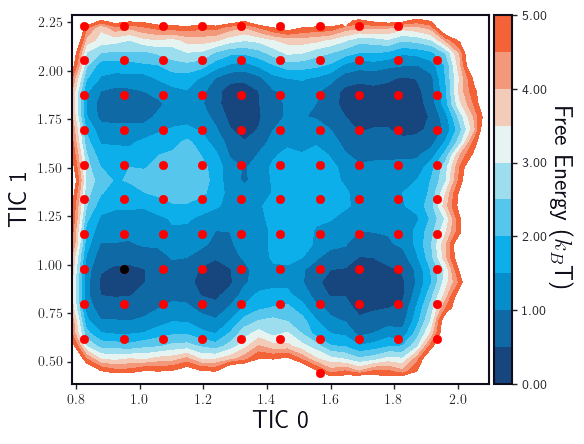

In [21]:
init_z, init_rc1_edge, init_rc2_edge = np.histogram2d(cv[:, 0], 
                                                      cv[:, 1],
                                                        bins=30)


init_rc1 = 0.5 * (init_rc1_edge[:-1] + init_rc1_edge[1:])
init_rc2 = 0.5 * (init_rc2_edge[:-1] + init_rc2_edge[1:])
init_z = init_z.T
init_z_density = init_z/float(init_z.sum())
init_free_energy = np.inf * np.ones(shape=init_z.shape)

nonzero = init_z_density.nonzero()
init_free_energy[nonzero] = -np.log(init_z_density[nonzero])
init_free_energy = init_free_energy - init_free_energy.min()

vmax = 5
plt.contourf(init_rc1, init_rc2, init_free_energy,
                levels=np.linspace(0, vmax, vmax * 2 + 1), cmap=rotskoff_cmap)
cbar = plt.colorbar(boundaries=np.linspace(0, vmax, vmax * 2 + 1), pad=0.01)
cbar.set_label(r"Free Energy ($k_B$T)", rotation=270, labelpad=20)
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
plt.scatter(centers[:, 0], centers[:, 1], color='red')
selected_idx = 12
plt.scatter(centers[selected_idx, 0], centers[selected_idx, 1], color='black')
# plt.scatter(fg_cv[fg_start, 0], fg_cv[fg_start, 1], color='blue')

plt.xlabel("TIC 0")
plt.ylabel("TIC 1")
# # plt.savefig("figures/trpcage/trpcage_schnet_free_energy.pdf", dpi=300)

In [22]:
cg_pdb = md.load("/global/cfs/cdirs/m4235/boltz_files/bba/bba.pdb")
print(cg_pdb.n_atoms)
cg_pdb = cg_pdb.atom_slice(cg_pdb.top.select("name CA or name C or name N"))
print(cg_pdb.n_atoms)
ca_indices = cg_pdb.top.select("name CA")
print(len(ca_indices))
alpha_indices = ca_indices[15:26]
beta_indices = ca_indices[3:15]

513
87
28


In [48]:
import torch.nn as nn
class BiasForceBBA(nn.Module):
    def __init__(self, centers: torch.Tensor, simulation_topology: md.Topology, bias_force:int =100.0):
        # simulation topology has the number of atoms you actually expect to simulate
        # for Boltz this means everything but the hydrogens
        # all positions should be in Angstroms
        super().__init__()
        self.centers = nn.Parameter(torch.tensor(centers, dtype=torch.float32))
        self.bias_force = bias_force
        self.batch_size = centers.shape[0]
        self.reference_ca = torch.tensor(ref_ca_p, dtype=torch.float32)
        self.reference_helix_ca = torch.tensor(helix_ca_p, dtype=torch.float32)

        ca_indices = simulation_topology.select("name CA")
        alpha_indices = ca_indices[15:26]
        beta_indices = ca_indices[3:15]


        self.alpha_indices = torch.tensor(alpha_indices, dtype=torch.long)
        self.beta_indices = torch.tensor(beta_indices, dtype=torch.long)

        self.ref_beta = self.reference_ca[:, 3:15, :]
        self.ref_beta = nn.Parameter(torch.cat([self.ref_beta for _ in range(self.batch_size)], dim=0))
        self.ref_helix = self.reference_helix_ca[:, 15:26, :]
        self.ref_helix = nn.Parameter(torch.cat([self.ref_helix for _ in range(self.batch_size)], dim=0))
        self.n_atoms = simulation_topology.n_atoms


    def rmsd(self, P: torch.Tensor, Q: torch.Tensor) -> torch.Tensor:
        """
        Compute RMSD per frame using Theobald's method (no explicit alignment).
        
        P: (n_frames, n_atoms, 3)
        Q: (n_frames, n_atoms, 3)

        Returns:
            rmsd_per_frame: (n_frames,)
        """
        # Center both structures
        P_centered = P - P.mean(dim=1, keepdim=True)
        Q_centered = Q - Q.mean(dim=1, keepdim=True)

        # Compute covariance matrix
        C = torch.matmul(P_centered.transpose(1, 2), Q_centered)  # (n_frames, 3, 3)

        # SVD on covariance matrix
        V, S, W = torch.linalg.svd(C)
        det = torch.det(torch.matmul(V, W.transpose(-1, -2)))
        sign_correction = det.sign()
        S_corrected = S.clone()
        S_corrected[:, -1] *= sign_correction  # fix last singular value

        dot = 2 * torch.sum(S_corrected, dim=-1)

        # Compute squared norms
        P_norm_sq = torch.sum(P_centered ** 2, dim=(1, 2))
        Q_norm_sq = torch.sum(Q_centered ** 2, dim=(1, 2))

        # RMSD² = (||P||² + ||Q||² - 2 * sum(S)) / N
        # dot = 2 * torch.sum(S, dim=-1)
        rmsd_sq = (P_norm_sq + Q_norm_sq - dot) / P.shape[1]
        # rmsd_sq = torch.clamp(rmsd_sq, min=0.0)

        return torch.sqrt(rmsd_sq)

    def transform_a(self, x: torch.Tensor) -> torch.Tensor:
        x = torch.log(x + 2)
        return x

    def transform_b(self, x: torch.Tensor) -> torch.Tensor:
        x = torch.log(x + 1)
        return x

    def get_cv(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        a = self.transform_a(self.rmsd(x[:, self.alpha_indices, :], self.ref_helix))
        b = self.transform_b(self.rmsd(x[:, self.beta_indices, :], self.ref_beta)) 
        return a, b

    def energy(self, x: torch.Tensor) -> torch.Tensor:
        # x is shape (batch, n_atoms, 3)
        alpha_cv, beta_cv = self.get_cv(x)

        alpha_cv = (self.centers[:, 0] - alpha_cv) ** 2
        beta_cv = (self.centers[:, 1] - beta_cv) ** 2
        energy = self.bias_force * (alpha_cv + beta_cv)
        return energy
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x is shape (batch, n_atoms, 3)
        # Ensure input tensor requires gradients
        if not x.requires_grad:
            x = x.clone().detach().requires_grad_(True)
        
        energy: torch.Tensor = self.energy(x)
        grad_outputs: List[Optional[torch.Tensor]] = [torch.ones_like(energy)]
        grad = torch.autograd.grad([energy], [x], create_graph=False,
                                    grad_outputs=grad_outputs)
        # optional type refinement using an if statement
        if grad is None:
            grad = torch.zeros_like(x)
            print("Warning: Gradient is None, returning zeros.", flush=True)
        else:
            grad = grad[0]
        
        # optional type refinement using an assert
        assert grad is not None
        # return grad # Now grad is always a torch.Tensor instead of Optional[torch.Tensor]
        return -grad

In [55]:
dir(unit)

['AVOGADRO_CONSTANT_NA',
 'BOLTZMANN_CONSTANT_kB',
 'BaseDimension',
 'BaseUnit',
 'GRAVITATIONAL_CONSTANT_G',
 'MOLAR_GAS_CONSTANT_R',
 'Quantity',
 'SPEED_OF_LIGHT_C',
 'ScaledUnit',
 'SiPrefix',
 'Unit',
 'UnitSystem',
 '__author__',
 '__builtins__',
 '__cached__',
 '__copyright__',
 '__credits__',
 '__doc__',
 '__docformat__',
 '__email__',
 '__file__',
 '__license__',
 '__loader__',
 '__maintainer__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'absolute_import',
 'acos',
 'acosh',
 'amount_dimension',
 'amp',
 'ampere',
 'ampere_base_unit',
 'amperes',
 'amps',
 'amu',
 'amus',
 'angle_dimension',
 'angstrom',
 'angstrom_base_unit',
 'angstroms',
 'arcminute',
 'arcminutes',
 'arcsecond',
 'arcseconds',
 'asin',
 'asinh',
 'atan',
 'atan2',
 'atanh',
 'atmosphere',
 'atmosphere_base_unit',
 'atmospheres',
 'atom_mass_units',
 'atomic_mass_unit',
 'atto',
 'attocalorie',
 'attocalorie_base_unit',
 'attocalories',
 'attogram',
 'attogram_base_unit',
 'attograms',
 'atto

In [54]:
(300 * unit.BOLTZMANN_CONSTANT_kB * unit.kelvin).value_in_unit(unit.kilocalorie / unit.mole)

TypeError: Unit "joule" is not compatible with Unit "kilocalorie/mole".

In [44]:
# bias_force = BiasForceBBA(centers, simulation_topology=bba_pdb.topology, bias_force=100.0)


In [46]:
bias_force = BiasForceBBA(centers, simulation_topology=boltz_pdb.topology, bias_force=100.0)
positions = torch.tensor(boltz_pdb.xyz * 10).repeat(100, 1, 1)
print(positions.shape)
bias_force(positions).shape

torch.Size([100, 250, 3])


torch.Size([100, 250, 3])

In [26]:
# p = torch.tensor(cg_pdb.xyz) * 10
# p = torch.concatenate([p for _ in range(100)], dim=0)
# p.requires_grad = True
# energy = bias_force(p)
# force = torch.autograd.grad(energy, p, create_graph=True, grad_outputs = torch.ones_like(energy))[0]
# force = force.detach().numpy().reshape(-1, 3)
# print(force.shape)
# force = np.linalg.norm(force, axis=1)
# force = force[force > 0]
# print(force.shape)
# plt.hist(force, bins=20, density=True)
# print(force.mean())

In [27]:
np.save("/global/cfs/cdirs/m4235/boltz_files/bba/batch_100.npy", np.arange(100))

In [28]:
centers.shape

(100, 2)

In [29]:
from glob import glob
#/global/cfs/cdirs/m4235/boltz_files/bba/boltz_inference/af3_server/bba_no_template_model_0.cif
#/global/cfs/cdirs/m4235/boltz_files/bba/boltz_inference/af3_server/bba_template_model_0.cif

# Take the sampled diffusion model structures and look at their RCs.

diffusion_structures = []
for filename in os.listdir("/global/cfs/cdirs/m4235/boltz_files/bba/boltz_inference/boltz_results_bba_inference/predictions/bba"):
    if filename.endswith(".pdb"):
        diffusion_structures.append(md.load(f"/global/cfs/cdirs/m4235/boltz_files/bba/boltz_inference/boltz_results_bba_inference/predictions/bba/{filename}"))
diffusion_structures = md.join(diffusion_structures)
diffusion_ca_top = diffusion_structures.topology.subset(diffusion_structures.topology.select("name CA"))
diffusion_ca = diffusion_structures.atom_slice(diffusion_structures.topology.select("name CA")).xyz * 10
# diffusion_rc = get_bba_rc(diffusion_ca, diffusion_ca_top)

# also look at the AF3 web server predictions with/without templates
template_af = []
for filename in glob("/global/cfs/cdirs/m4235/boltz_files/bba/boltz_inference/af3_server/bba_template_model_*.cif"):
    template_af.append(md.load(filename))
template_af = md.join(template_af)
template_af_ca_top = template_af.topology.subset(template_af.topology.select("name CA"))
template_af_ca = template_af.atom_slice(template_af.topology.select("name CA")).xyz * 10
# template_af_rc = get_bba_rc(template_af_ca, template_af_ca_top) 

no_template_af = []
for filename in glob("/global/cfs/cdirs/m4235/boltz_files/bba/boltz_inference/af3_server/bba_no_template_model_*.cif"):
    no_template_af.append(md.load(filename))
no_template_af = md.join(no_template_af)
no_template_af_ca_top = no_template_af.topology.subset(no_template_af.topology.select("name CA"))
no_template_af_ca = no_template_af.atom_slice(no_template_af.topology.select("name CA")).xyz * 10
# no_template_af_rc = get_bba_rc(no_template_af_ca, no_template_af_ca_top)


In [30]:
p = torch.tensor(diffusion_structures.xyz * 10, dtype=torch.float32)
print(p.shape)
p.requires_grad = True
force = bias_force(p)
force = force.detach().numpy().reshape(-1, 3)
force = np.linalg.norm(force, axis=1)
force = force[force > 1e-3]
print(force.shape)
plt.hist(force, bins=20, density=True)
print(force.mean())

torch.Size([2000, 250, 3])


RuntimeError: shape '[100, 250, 3]' is invalid for input of size 1500000

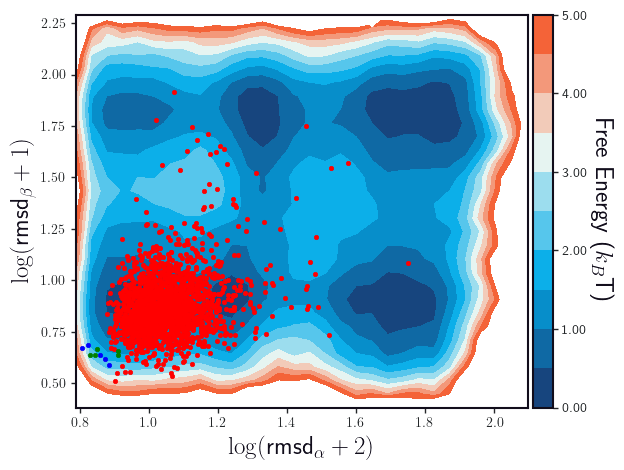

In [30]:

diffusion_rc = get_bba_rc(diffusion_ca, diffusion_ca_top)
template_af_rc = get_bba_rc(template_af_ca, template_af_ca_top) 
no_template_af_rc = get_bba_rc(no_template_af_ca, no_template_af_ca_top)


init_z, init_rc1_edge, init_rc2_edge = np.histogram2d(cv[:, 0], 
                                                      cv[:, 1],
                                                        bins=30)


init_rc1 = 0.5 * (init_rc1_edge[:-1] + init_rc1_edge[1:])
init_rc2 = 0.5 * (init_rc2_edge[:-1] + init_rc2_edge[1:])
init_z = init_z.T
init_z_density = init_z/float(init_z.sum())
init_free_energy = np.inf * np.ones(shape=init_z.shape)

nonzero = init_z_density.nonzero()
init_free_energy[nonzero] = -np.log(init_z_density[nonzero])
init_free_energy = init_free_energy - init_free_energy.min()

vmax = 5
plt.contourf(init_rc1, init_rc2, init_free_energy,
                levels=np.linspace(0, vmax, vmax * 2 + 1), cmap=rotskoff_cmap)
cbar = plt.colorbar(boundaries=np.linspace(0, vmax, vmax * 2 + 1), pad=0.01)
cbar.set_label(r"Free Energy ($k_B$T)", rotation=270, labelpad=20)
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
plt.scatter(diffusion_rc[:, 0], diffusion_rc[:, 1], color='red', label='Boltz1 Samples', s=10)
plt.scatter(template_af_rc[:, 0], template_af_rc[:, 1], color='green', label='Template AF3 Samples', s=10)
plt.scatter(no_template_af_rc[:, 0], no_template_af_rc[:, 1], color='blue', label='No Template AF3 Samples', s=10)

plt.xlabel(r"$\log (\text{rmsd}_\alpha + 2)$")
plt.ylabel(r"$\log (\text{rmsd}_\beta + 1)$")
# plt.legend(bbox_to_anchor=(1.35, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [102]:
bias_force = BiasForceBBA(centers=centers, simulation_topology=diffusion_structures.topology, bias_force=500.0)
scripted_bias_force = torch.jit.script(bias_force)
torch.jit.save(scripted_bias_force, "/global/cfs/cdirs/m4235/boltz_files/bba/bias_force_bba_500.pt")

In [50]:
loaded_bias_force = torch.jit.load("/global/cfs/cdirs/m4235/boltz_files/bba/bias_force_bba_100.pt")

positions = torch.tensor(diffusion_structures.xyz[:100] * 10)
force = loaded_bias_force(positions)
print(force.shape)
# force = torch.autograd.grad(energy, positions, create_graph=True, grad_outputs = torch.ones_like(energy))[0]


torch.Size([100, 250, 3])


In [ ]:
import h5py
sampled_positions = []
for file in glob("/global/cfs/cdirs/m4235/boltz_files/bba/boltz_results_bba_umbrella_test4/umbrella_0/cg_dataset_*.hdf5"):
    with h5py.File(file, "r") as file:
        sampled_positions.append(torch.tensor(file["positions"][:]))
sampled_positions = torch.cat(sampled_positions, dim=0)
print("Before subsampling:", sampled_positions.shape) # (frames, windows, atoms, 3)
# count the number of nonzero frames
print(f"{(sampled_positions != 0.0).all((1,2,3)).sum()} nonzero out of {sampled_positions.shape[0]}")
print(f"{(sampled_positions.isinf()).all((1,2,3)).sum()} inf out of {sampled_positions.shape[0]}")

invalid = ((sampled_positions == 0.0).all((1,2,3)) | (sampled_positions.isinf()).all((1,2,3)))
sampled_positions = sampled_positions[~invalid]
print("After removing invalid frames:", sampled_positions.shape) # (frames, windows, atoms,

num_frames = sampled_positions.shape[0]
sampled_positions = sampled_positions[::100]
print("After subsampling:", sampled_positions.shape) # (frames, windows, atoms, 3)

Before subsampling: torch.Size([2000, 100, 250, 3])
1472 nonzero out of 2000
0 inf out of 2000
After removing invalid frames: torch.Size([1472, 100, 250, 3])
After subsampling: torch.Size([15, 100, 250, 3])


In [99]:
torch.norm(sampled_positions[0,0,0,:] - sampled_positions[0,0,1,:], dim=-1)

tensor(1.4744)

In [100]:
sampled_rcs = get_bba_rc(rearrange(sampled_positions, "frame window atom dim -> (frame window) atom dim"), 
                 diffusion_structures.topology)
# sampled_rcs = rearrange(sampled_rcs, "(frame window) dim -> frame window dim", frame=num_frames)
print(sampled_rcs.shape)



(1500, 2)


/tmp/ipykernel_666203/1808049288.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  P = torch.tensor(P, dtype=torch.float32)


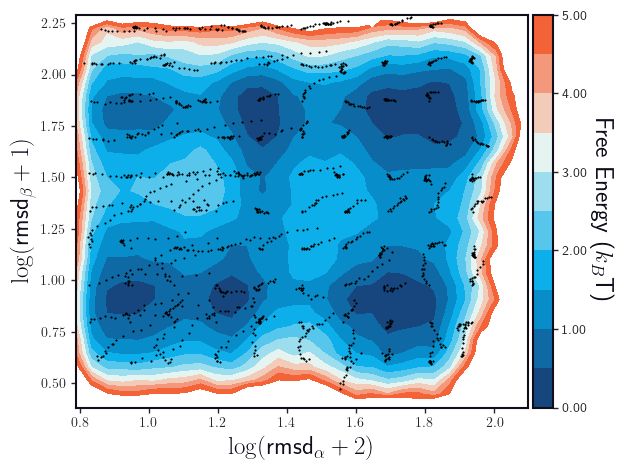

In [101]:
init_z, init_rc1_edge, init_rc2_edge = np.histogram2d(cv[:, 0], 
                                                      cv[:, 1],
                                                        bins=30)


init_rc1 = 0.5 * (init_rc1_edge[:-1] + init_rc1_edge[1:])
init_rc2 = 0.5 * (init_rc2_edge[:-1] + init_rc2_edge[1:])
init_z = init_z.T
init_z_density = init_z/float(init_z.sum())
init_free_energy = np.inf * np.ones(shape=init_z.shape)

nonzero = init_z_density.nonzero()
init_free_energy[nonzero] = -np.log(init_z_density[nonzero])
init_free_energy = init_free_energy - init_free_energy.min()

vmax = 5
plt.contourf(init_rc1, init_rc2, init_free_energy,
                levels=np.linspace(0, vmax, vmax * 2 + 1), cmap=rotskoff_cmap)
cbar = plt.colorbar(boundaries=np.linspace(0, vmax, vmax * 2 + 1), pad=0.01)
cbar.set_label(r"Free Energy ($k_B$T)", rotation=270, labelpad=20)
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
plt.scatter(sampled_rcs[:, 0], sampled_rcs[:, 1], color='black', label='Boltz1 Samples', s=1)

plt.xlabel(r"$\log (\text{rmsd}_\alpha + 2)$")
plt.ylabel(r"$\log (\text{rmsd}_\beta + 1)$")
# plt.legend(bbox_to_anchor=(1.35, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [103]:
# save the trajectory as a pdb file at the selected index
selected_pos = sampled_positions[:,selected_idx,:,:].clone()/10
selected_traj = md.Trajectory(selected_pos.numpy(), diffusion_structures.topology).center_coordinates()
selected_traj.save("selected_traj.pdb")

In [ ]:
loaded_bias_force = torch.jit.load("/global/cfs/cdirs/m4235/boltz_files/bba/bias_force_bba_100.pt")
loaded_bias_force.energy

(array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0.,
        0., 1., 0., 0., 0., 1., 1., 1., 1., 1., 0., 8., 3., 6., 3., 5., 4.,
        1., 5., 5., 4., 9., 4., 5., 8., 6., 6., 3., 2., 2., 1., 0., 1.]),
 array([11.03720951, 11.05708122, 11.07695293, 11.09682465, 11.11669636,
        11.13656807, 11.15643978, 11.17631149, 11.1961832 , 11.21605396,
        11.23592567, 11.25579739, 11.2756691 , 11.29554081, 11.31541252,
        11.33528423, 11.35515594, 11.37502766, 11.39489937, 11.41477108,
        11.43464279, 11.4545145 , 11.47438622, 11.49425793, 11.51412964,
        11.5340004 , 11.55387211, 11.57374382, 11.59361553, 11.61348724,
        11.63335896, 11.65323067, 11.67310238, 11.69297409, 11.7128458 ,
        11.73271751, 11.75258923, 11.77246094, 11.79233265, 11.81220436,
        11.83207607, 11.85194778, 11.87181854, 11.89169025, 11.91156197,
        11.93143368, 11.95130539, 11.9711771 , 11.99104881, 12.01092052,
        12.03079224]),
 <BarContainer object

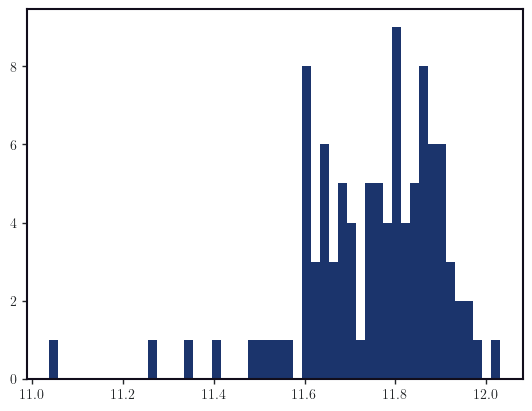

In [88]:
# load the starting coordinates

start_pos = torch.load("/global/cfs/cdirs/m4235/boltz_files/bba/boltz_results_bba_umbrella_test2/umbrella_1/starting_coords.pt").to("cpu")

# find the minimum distance between two atoms in each frame
all_dists = torch.norm(start_pos[:, None, :, :] - start_pos[:, :, None, :], dim=-1)
all_dists = all_dists + torch.eye(all_dists.shape[1])[None, :, :] * 1e6
min_dists = torch.amin(all_dists, dim=(1, 2), )
plt.hist(min_dists.numpy(), bins=50)

In [93]:
start_traj = md.load("/global/cfs/cdirs/m4235/boltz_files/bba/umbrella/all_bba_start_positions.pdb")
print(start_traj.n_frames)
pos = torch.tensor(start_traj.xyz * 10, dtype=torch.float32)
torch.norm(pos[0,0,:] - pos[0,1,:], dim=-1)

100


tensor(1.1112)